# Project 2 — From Unstructured Service Feedback to Actionable Intelligence
## 01 · Text quality, privacy, unsupervised discovery

> Synthetic demo text (`common/synthetic.py`). No message is a real customer's or provider's.

### Analytical question
What is actually in the feedback corpus, and what must be removed before any model sees it?

### Evidence so far
Nothing yet.

### Why this approach?
Free text is where privacy failures happen. Quality filtering and PII redaction run first and are *counted*; discovery (TF-IDF + NMF) then tells us which themes exist before we commit to a taxonomy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
from project2_feedback_nlp.src import quality, privacy, discovery, taxonomy
fb = pd.read_csv('data/synthetic/feedback.csv', parse_dates=['created_at']).drop(columns='true_theme')
fb, qrep = quality.apply(fb); kept = fb[fb.exclusion_reason=='']
kept, prep = privacy.apply(kept)
qrep, prep

({'n_input': 1560,
  'n_kept': 1311,
  'exclusions': {'exact_duplicate': 182,
   'too_short': 39,
   'empty': 21,
   'non_english': 7},
  'median_tokens_kept': 16.0},
 {'n_docs': 1311,
  'share_docs_with_pii': 0.19221967963386727,
  'entities_by_type': {'POSTCODE': 44, 'EMAIL': 65, 'PHONE': 133, 'NAME': 19}})

### Interpretation
~15% of records are excluded (duplicates, empty, too short, non-English) and ~20% of the remainder contain at least one identifier. Redacted text (`text_redacted`) is the only column any later step touches. Exclusion counts are reported so that volume monitoring is not distorted.

,k,coherence,stability
0,4,2.793124,0.871795
1,6,2.687623,0.622222
2,8,2.968836,0.637326
3,10,2.978989,0.611948
4,12,3.143724,0.597528


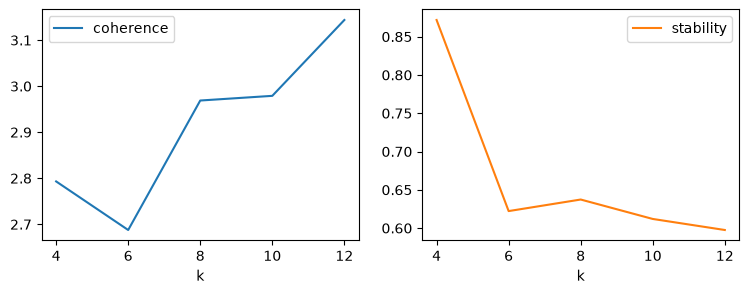

In [2]:
vec, X = discovery.vectorise(kept.text_redacted); vocab = vec.get_feature_names_out()
kdf = discovery.choose_k(X, vocab, [4,6,8,10,12]); kdf.plot(x='k', subplots=True, layout=(1,2), figsize=(9,3)); kdf

In [3]:
_, W, terms = discovery.fit_topics(X, vocab, 8)
taxonomy.map_topics_to_taxonomy(terms)

,topic,top_terms,mapped_category,overlap
0,0,"time, happened, time happened, second time, se...",app_bug,1
1,1,"shows, profile photo, shows sideways, sideways...",NEW/uncovered,0
2,2,"hours, arrive, late miss, notifications arrive...",provider_no_show,1
3,3,"lead, twice, heard, filled, paid lead, paid, s...",provider_communication,1
4,4,"penny, sense, makes sense, way actually, makes...",workmanship_quality,1
5,5,"days, waiting, enquiry, money fake, fake, prom...",provider_no_show,1
6,6,"update, coverage zones, save, coverage, zones ...",app_bug,3
7,7,"loop android, login, login loop, loop, android...",NEW/uncovered,0


### Interpretation / Decision
Coherence and stability are both reasonable around k=8; topics map onto recognisable operational issues (refunds, no-shows, app problems, lead quality). One or two topics are lexically driven (e.g. 'clean' appearing in praise) — that is exactly why topics are evidence for a taxonomy, not the taxonomy itself (D2).